# 📊 Notebook 03: Evaluation & Business Insights
### Project: Professional Customer Segmentation & CLV Prediction

This notebook generates final clustering metrics, business insights (Pareto Analysis), and visual assets for the dashboard.

In [1]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, mean_absolute_error, r2_score

# Base paths
BASE_DIR = os.path.dirname(os.getcwd()) if "notebooks" in os.getcwd() else os.getcwd()
PROCESSED_DATA = os.path.join(BASE_DIR, 'data', 'processed', 'rfm_clv_data.csv')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
CHARTS_DIR = os.path.join(BASE_DIR, 'charts')

df = pd.read_csv(PROCESSED_DATA, index_col=0)

with open(os.path.join(MODELS_DIR, 'scaler.pkl'), 'rb') as f:
    scaler = pickle.load(f)
with open(os.path.join(MODELS_DIR, 'transformer.pkl'), 'rb') as f:
    pt = pickle.load(f)

print(f"Loaded results for {len(df)} customers.")

Loaded results for 4933 customers.


## 1. Clustering Quality Metrics
Evaluating how well the segments are separated.

In [2]:
features = ['Recency', 'Frequency', 'Monetary']
X_transformed = pt.transform(df[features])
X_scaled = scaler.transform(X_transformed)

sc = silhouette_score(X_scaled, df['Cluster'])
ch = calinski_harabasz_score(X_scaled, df['Cluster'])
db = davies_bouldin_score(X_scaled, df['Cluster'])

print(f"Silhouette Score: {sc:.4f}")
print(f"Calinski-Harabasz: {ch:.2f}")
print(f"Davies-Bouldin: {db:.4f}")

# Save to CSV
metrics_df = pd.DataFrame({
    'Metric': ['Silhouette Score', 'Calinski-Harabasz', 'Davies-Bouldin'],
    'Value': [sc, ch, db]
})
metrics_df.to_csv(os.path.join(MODELS_DIR, 'performance_metrics.csv'), index=False)
print("Clustering metrics saved.")

Silhouette Score: 0.3804
Calinski-Harabasz: 4499.72
Davies-Bouldin: 0.9017
Clustering metrics saved.


## 2. Business Insights: Pareto Analysis (80/20 Rule)
Quantifying exactly how many customers drive the majority of your revenue.

PARETO FINDING: 24.81% of customers drive 80% of total revenue.


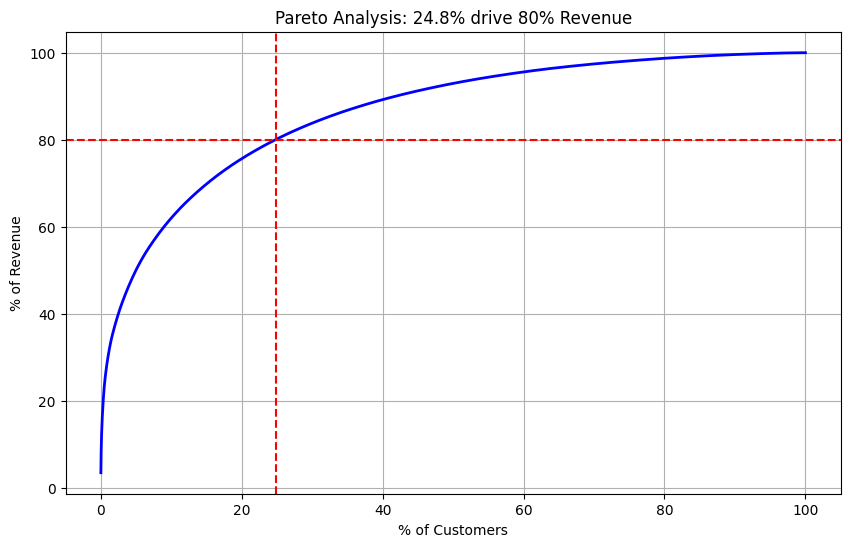

In [3]:
df_pareto = df[['Monetary']].copy()
df_pareto = df_pareto.sort_values(by='Monetary', ascending=False)
df_pareto['CumulativeSpend'] = df_pareto['Monetary'].cumsum()
df_pareto['%Spend'] = 100 * df_pareto['CumulativeSpend'] / df_pareto['Monetary'].sum()
df_pareto['%Customers'] = 100 * (np.arange(len(df_pareto)) + 1) / len(df_pareto)

# Get the percentage of customers at 80% revenue
cutoff_80 = df_pareto[df_pareto['%Spend'] >= 80].iloc[0]
print(f"PARETO FINDING: {cutoff_80['%Customers']:.2f}% of customers drive 80% of total revenue.")

plt.figure(figsize=(10, 6))
plt.plot(df_pareto['%Customers'], df_pareto['%Spend'], color='blue', lw=2)
plt.axvline(x=cutoff_80['%Customers'], color='red', linestyle='--')
plt.axhline(y=80, color='red', linestyle='--')
plt.title(f'Pareto Analysis: {cutoff_80["%Customers"]:.1f}% drive 80% Revenue')
plt.xlabel('% of Customers')
plt.ylabel('% of Revenue')
plt.grid(True)
plt.savefig(os.path.join(CHARTS_DIR, 'pareto_analysis.png'))
plt.show()

## 3. 3D Cluster Visualization
The strongest visual asset for a portfolio.

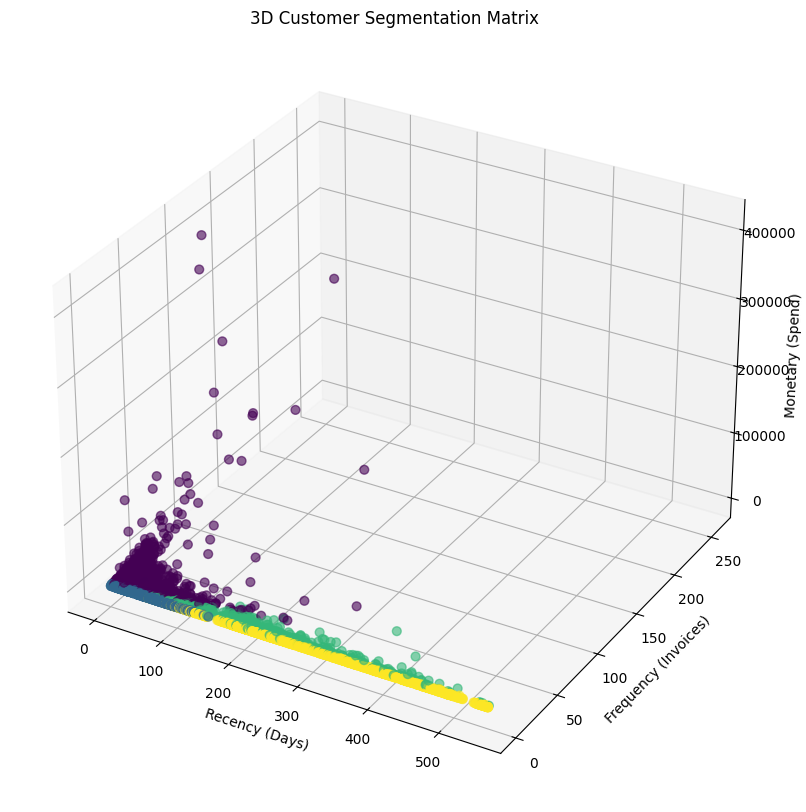

In [4]:
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(df['Recency'], df['Frequency'], df['Monetary'], 
                     c=df['Cluster'], cmap='viridis', 
                     marker='o', s=40, alpha=0.6)

ax.set_xlabel('Recency (Days)')
ax.set_ylabel('Frequency (Invoices)')
ax.set_zlabel('Monetary (Spend)')
ax.set_title('3D Customer Segmentation Matrix')

plt.savefig(os.path.join(CHARTS_DIR, 'rfm_3d_scatter.png'))
plt.show()